In [19]:
import pandas as pd
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib

## Load Dataset

In [2]:
df = pd.read_csv("Data/amazon_product_details.csv", usecols=['category', 'about_product', 'product_name'])

In [3]:
df['category'] = df['category'].apply(lambda x: x.split('|')[-1])

In [4]:
df['category'].value_counts()

category
USBCables               233
SmartWatches             76
Smartphones              68
SmartTelevisions         63
In-Ear                   52
                       ... 
RotiMakers                1
FanParts&Accessories      1
StandMixers               1
PedestalFans              1
HandheldBags              1
Name: count, Length: 207, dtype: int64

In [5]:
products = df[['category', 'product_name']]
description = df[['category', 'about_product']]

In [6]:
products = products.rename(columns={'product_name': 'text'})
description = description.rename(columns={'about_product': 'text'})

products['task_type'] = 'Product Name'
description['task_type'] = 'Product Description'

In [7]:
description

,category,text,task_type
0,USBCables,High Compatibility : Compatible With iPhone 12...,Product Description
1,USBCables,"Compatible with all Type C enabled devices, be...",Product Description
2,USBCables,【 Fast Charger& Data Sync】-With built-in safet...,Product Description
3,USBCables,The boAt Deuce USB 300 2 in 1 cable is compati...,Product Description
4,USBCables,[CHARGE & SYNC FUNCTION]- This cable comes wit...,Product Description
...,...,...,...
1460,WaterPurifierAccessories,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,Product Description
1461,Rice&PastaCookers,"230 Volts, 400 watts, 1 Year",Product Description
1462,HeatConvectors,International design and styling|Two heat sett...,Product Description
1463,ExhaustFans,Fan sweep area: 230 MM ; Noise level: (40 - 45...,Product Description


In [8]:
df = pd.concat([products, description], ignore_index=True)

In [9]:
df


,category,text,task_type
0,USBCables,Wayona Nylon Braided USB to Lightning Fast Cha...,Product Name
1,USBCables,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Product Name
2,USBCables,Sounce Fast Phone Charging Cable & Data Sync U...,Product Name
3,USBCables,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Product Name
4,USBCables,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Product Name
...,...,...,...
2925,WaterPurifierAccessories,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,Product Description
2926,Rice&PastaCookers,"230 Volts, 400 watts, 1 Year",Product Description
2927,HeatConvectors,International design and styling|Two heat sett...,Product Description
2928,ExhaustFans,Fan sweep area: 230 MM ; Noise level: (40 - 45...,Product Description


In [10]:
dataset = Dataset.from_pandas(df)
dataset = dataset.shuffle(seed=0)
dataset = dataset.train_test_split(test_size=0.1)

In [11]:
dataset


DatasetDict({
    train: Dataset({
        features: ['category', 'text', 'task_type'],
        num_rows: 2637
    })
    test: Dataset({
        features: ['category', 'text', 'task_type'],
        num_rows: 293
    })
})

In [12]:
dataset['test'][3]

{'category': 'DigitalKitchenScales',
 'text': 'HealthSense Chef-Mate KS 33 Digital Kitchen Weighing Scale & Food Weight Machine for Health, Fitness, Home Baking & Cooking with Free Bowl, 1 Year Warranty & Batteries Included',
 'task_type': 'Product Name'}

## Hist Plot


In [20]:
# 1.5 times of total words
products['text_tokens'] = products['text'].apply(lambda x: len(x.split())*1.5)
description['text_tokens'] = description['text'].apply(lambda x: len(x.split())*1.5)

<Axes: >

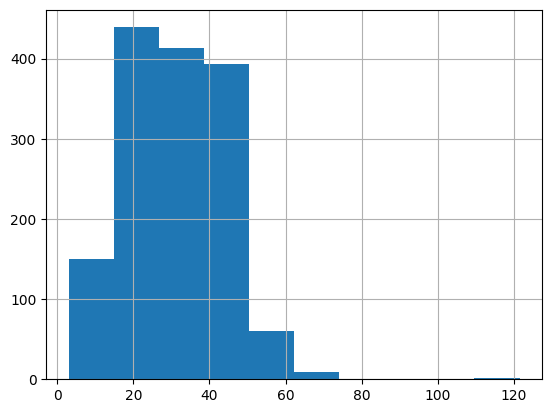

In [21]:
products['text_tokens'].hist()


<Axes: >

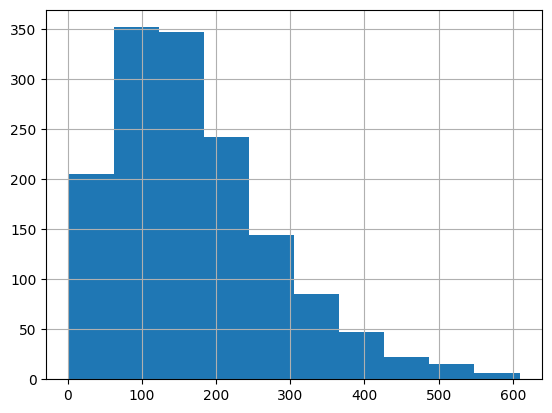

In [22]:
description['text_tokens'].hist()